# Weak Lensing Forward Model — working notebook

Ashok Kumar Ramu, 2026

Trying to build a forward model for weak lensing shear statistics in flat LCDM.
Main motivation is understanding what UNIONS and Euclid are actually measuring
before I try any parameter inference on top.

Physics chain I want:
(Omega_m, sigma_8) -> P(k) -> D(z) -> W(chi) -> C_l -> xi_+(theta), xi_-(theta)

Everything from scratch, numpy/scipy only.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Ellipse
from scipy import integrate, interpolate
from scipy.special import jv
import os

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
    'figure.figsize': (8, 5),
})

# colourblind-safe palette from Wong (2011)
BLUE   = '#0077BB'
RED    = '#CC3311'
GREEN  = '#009988'
ORANGE = '#EE7733'
PURPLE = '#AA3377'

COLORS_5 = [BLUE, GREEN, ORANGE, RED, PURPLE]

## Cosmological parameters

In [2]:
# Planck 2018 (Aghanim et al. 2020, Table 2, TT+TE+EE+lowE)
OMEGA_B = 0.0486
H0      = 67.3       # km/s/Mpc
h       = H0 / 100
N_S     = 0.9649
C_LIGHT = 2.998e5    # km/s

PLANCK_OMEGA_M = 0.315
PLANCK_SIGMA8  = 0.811
PLANCK_S8      = PLANCK_SIGMA8 * np.sqrt(PLANCK_OMEGA_M / 0.3)

# KiDS-1000 (Asgari et al. 2021)
KIDS_S8     = 0.766
KIDS_S8_ERR = 0.017

# DES Y3 (Amon et al. 2022)
DES_S8     = 0.776
DES_S8_ERR = 0.017

tension = (PLANCK_S8 - KIDS_S8) / KIDS_S8_ERR
print(f'Planck S8 = {PLANCK_S8:.3f}')
print(f'KiDS  S8 = {KIDS_S8:.3f} +/- {KIDS_S8_ERR}')
print(f'tension  = {tension:.1f} sigma')

Planck S8 = 0.831
KiDS  S8 = 0.766 +/- 0.017
tension  = 3.8 sigma


## FLRW background

Starting with comoving distance chi(z). First tried doing the integral with a fixed
z grid but it was slow for the growth factor later. Kept the loop but with a denser
internal grid inside each call. Should vectorize properly at some point.

Note to self: chi(z=1100) should come out ~14000 Mpc (CMB surface of last scattering).

In [3]:
# first pass -- kept this commented as a reminder of what not to do
# was doing quad() inside a loop over z_arr which was fine but overkill
# def chi_slow(z, Omega_m):
#     integrand = lambda zp: 1.0 / np.sqrt(Omega_m*(1+zp)**3 + (1-Omega_m))
#     result, _ = integrate.quad(integrand, 0, z)
#     return (C_LIGHT / H0) * result

def E(z, Omega_m):
    # H(z)/H0 for flat LCDM
    return np.sqrt(Omega_m * (1 + z)**3 + (1.0 - Omega_m))

def chi_of_z(z_arr, Omega_m):
    # comoving distance in Mpc
    chi = np.zeros_like(z_arr, dtype=float)
    for i, z in enumerate(z_arr):
        if z <= 0:
            continue
        z_int = np.linspace(0, z, 500)
        chi[i] = (C_LIGHT / H0) * np.trapezoid(1.0 / E(z_int, Omega_m), z_int)
    return chi

# sanity check: should be ~14000 Mpc
chi_cmb = chi_of_z(np.array([1100.0]), PLANCK_OMEGA_M)[0]
print(f'chi(z=1100) = {chi_cmb:.0f} Mpc  (expect ~14000)')

chi(z=1100) = 14963 Mpc  (expect ~14000)


In [4]:
def growth_factor(z_arr, Omega_m):
    # D(z) from Heath (1977), normalized so D(0)=1
    # D proportional to H(z) * int_z^inf (1+z)/H^3 dz
    def integrand(zp):
        return (1 + zp) / E(zp, Omega_m)**3
    norm, _ = integrate.quad(integrand, 0, np.inf)
    D = np.zeros_like(z_arr, dtype=float)
    for i, z in enumerate(z_arr):
        Dz, _ = integrate.quad(integrand, z, np.inf)
        D[i]  = E(z, Omega_m) * Dz / (E(0, Omega_m) * norm)
    return D

Z_ARR = np.linspace(0.01, 3.0, 300)

# quick check -- should decrease from ~1 at low z
D_test = growth_factor(np.array([0.01, 0.5, 1.0, 2.0]), PLANCK_OMEGA_M)
print('D(z) at z=0.01, 0.5, 1.0, 2.0:', np.round(D_test, 3))

D(z) at z=0.01, 0.5, 1.0, 2.0: [0.995 0.769 0.607 0.417]


## Matter power spectrum P(k)

Using Eisenstein & Hu (1998) transfer function -- handles baryons properly,
unlike BBKS. Good to ~5% for standard LCDM.

The sigma_8 normalization is a bit annoying: integrate P(k)*W_TH(kR)^2 over
all k (R=8 Mpc/h tophat), set equal to sigma_8^2, then solve for A_s.

In [5]:
def transfer_function_EH(k, Omega_m):
    # Eisenstein & Hu (1998) -- k in h/Mpc
    Omega_b = OMEGA_B
    Omega_c = Omega_m - Omega_b
    ombh2 = Omega_b * h**2
    ommh2 = Omega_m * h**2

    z_eq   = 2.5e4 * ommh2 * (2.7255/2.7)**(-4)
    k_eq   = 7.46e-2 * ommh2 * (2.7255/2.7)**(-2)
    b1     = 0.313 * ommh2**(-0.419) * (1 + 0.607*ommh2**0.674)
    b2     = 0.238 * ommh2**0.223
    z_d    = 1291 * ommh2**0.251 / (1 + 0.659*ommh2**0.828) * (1 + b1*ombh2**b2)
    R_eq   = 31.5e3 * ombh2 * (2.7255/2.7)**(-4) * (1000/z_eq)
    R_d    = 31.5e3 * ombh2 * (2.7255/2.7)**(-4) * (1000/z_d)
    s      = (2/(3*k_eq)) * np.sqrt(6/R_eq) * np.log(
               (np.sqrt(1+R_d) + np.sqrt(R_d+R_eq)) / (1 + np.sqrt(R_eq)))
    k_silk = 1.6 * ombh2**0.52 * ommh2**0.38 / (1 + (5.2*ommh2)**(-0.46))

    a1      = (46.9*ommh2)**0.670 * (1 + (32.1*ommh2)**(-0.532))
    a2      = (12.0*ommh2)**0.424 * (1 + (45.0*ommh2)**(-0.582))
    alpha_c = a1**(-Omega_b/Omega_m) * a2**(-(Omega_b/Omega_m)**3)
    bb1     = 0.944 / (1 + (458*ommh2)**(-0.708))
    bb2     = (0.395*ommh2)**(-0.0266)
    beta_c  = 1 / (1 + bb1*((Omega_c/Omega_m)**bb2 - 1))

    def T0(k, alpha, beta):
        q  = k / (13.41*k_eq)
        C  = 14.2/alpha + 386/(1 + 69.9*q**1.08)
        ln = np.log(np.e + 1.8*beta*q)
        return ln / (ln + C*q**2)

    f  = 1 / (1 + (k*s/5.4)**4)
    Tc = f*T0(k, 1, beta_c) + (1-f)*T0(k, alpha_c, 1)

    y        = z_eq / (1 + z_d)
    G        = y * (-6*np.sqrt(1+y) + (2+3*y)*np.log((np.sqrt(1+y)+1)/(np.sqrt(1+y)-1)))
    alpha_b  = 2.07*k_eq*s*(1+R_d)**(-3/4)*G
    beta_b   = 0.5 + Omega_b/Omega_m + (3 - 2*Omega_b/Omega_m)*np.sqrt((17.2*ommh2)**2+1)
    beta_node= 8.41*ommh2**0.435
    s_tilde  = s / (1 + (beta_node/(k*s))**3)**(1/3)
    j0       = np.sinc(k*s_tilde/np.pi)
    Tb       = (T0(k,1,1)/(1+(k*s/5.2)**2) +
                alpha_b/(1+(beta_b/(k*s))**3) * np.exp(-(k/k_silk)**1.4)) * j0

    return Omega_b/Omega_m * Tb + Omega_c/Omega_m * Tc


def normalize_pk(Omega_m, sigma8):
    k   = np.logspace(-4, 2, 1000)
    R   = 8.0  # Mpc/h
    x   = k * R
    W   = 3*(np.sin(x) - x*np.cos(x)) / x**3  # tophat window in k-space
    T   = transfer_function_EH(k, Omega_m)
    intg = np.trapezoid(k**2 * k**N_S * T**2 * W**2, np.log(k))
    s8u  = np.sqrt(intg / (2*np.pi**2))
    return (sigma8 / s8u)**2


def power_spectrum(k, Omega_m, sigma8):
    A_s = normalize_pk(Omega_m, sigma8)
    T   = transfer_function_EH(k, Omega_m)
    return A_s * k**N_S * T**2

print('transfer function ok')

transfer function ok


## Lensing kernel W(chi) and shear statistics

The prefactor (3/2)(H0/c)^2 * Omega_m in W(chi) tripped me up at first.
It comes from the Poisson equation in comoving coords + GR light deflection --
most review papers just quote the Limber result without showing where it comes from.

Note on the Hankel transform: xi_+ uses J_0, xi_- uses J_4.
I had J_2 for xi_- first and got garbage. Correct orders come from the spin-2
nature of the shear field -- see Bartelmann & Schneider (2001) eq. 2.69.

Limber approximation valid for ell >> 1, so basically our whole range.
See Loverde & Afshordi (2008) for extended Limber if we need it later.

In [6]:
def source_nz(z_mean=0.5, alpha=1.5, beta=2.0):
    # parametric n(z) -- not the real UNIONS n(z), just something plausible
    nz  = (Z_ARR/z_mean)**alpha * np.exp(-(Z_ARR/z_mean)**beta)
    nz /= np.trapezoid(nz, Z_ARR)
    return nz

NZ_ARR = source_nz()


def lensing_kernel(Omega_m):
    # W(chi) = (3/2)(H0/c)^2 * Omega_m * chi/a * int_chi^chiH n(chi')(chi'-chi)/chi' dchi'
    chi_arr   = chi_of_z(Z_ARR, Omega_m)
    Hz        = H0 * E(Z_ARR, Omega_m)
    nchi      = NZ_ARR * Hz / C_LIGHT   # n(z) -> n(chi) via dz/dchi = H(z)/c
    a_arr     = 1.0 / (1.0 + Z_ARR)
    prefactor = 1.5 * (H0/C_LIGHT)**2 * Omega_m

    W_arr = np.zeros(len(Z_ARR))
    for i, (chi_i, a_i) in enumerate(zip(chi_arr, a_arr)):
        mask = chi_arr > chi_i
        if mask.sum() < 2:
            continue
        intg     = nchi[mask] * (chi_arr[mask] - chi_i) / chi_arr[mask]
        W_arr[i] = prefactor * (chi_i/a_i) * np.trapezoid(intg, chi_arr[mask])

    return chi_arr, W_arr


ELL_ARR = np.unique(np.geomspace(2, 2000, 80).astype(int)).astype(float)


def compute_Cl(Omega_m, sigma8):
    # Limber: C_l = int dchi W^2(chi)/chi^2 * P(k=(l+0.5)/chi, z(chi)) * D(z)^2
    chi_arr, W_arr = lensing_kernel(Omega_m)
    z_of_chi = interpolate.interp1d(chi_arr, Z_ARR,
                                    bounds_error=False, fill_value='extrapolate')
    W_interp = interpolate.interp1d(chi_arr, W_arr,
                                    bounds_error=False, fill_value=0.0)
    chi_int  = np.linspace(chi_arr[5], chi_arr[-1], 200)
    W_int    = W_interp(chi_int)
    z_int    = z_of_chi(chi_int)
    D_int    = growth_factor(z_int, Omega_m)

    Cl = np.zeros(len(ELL_ARR))
    for i, ell in enumerate(ELL_ARR):
        k_limber = (ell + 0.5) / chi_int
        Pk_z     = power_spectrum(k_limber, Omega_m, sigma8) * D_int**2
        Cl[i]    = np.trapezoid(W_int**2 / chi_int**2 * Pk_z, chi_int)

    return ELL_ARR, Cl


THETA_ARCMIN = np.array([1, 2, 4, 7, 12, 20, 35, 60, 100, 180, 300])
THETA_RAD    = THETA_ARCMIN * (np.pi / 180 / 60)


def compute_xi(Omega_m, sigma8):
    # xi_+ uses J_0, xi_- uses J_4 (NOT J_2 -- I made that mistake first)
    ell, Cl   = compute_Cl(Omega_m, sigma8)
    ell_fine  = np.linspace(ell[0], ell[-1], 8000)
    Cl_fine   = np.interp(ell_fine, ell, Cl)

    xi_plus = np.array([
        np.trapezoid(ell_fine * Cl_fine * jv(0, ell_fine*theta), ell_fine) / (2*np.pi)
        for theta in THETA_RAD
    ])
    xi_minus = np.array([
        np.trapezoid(ell_fine * Cl_fine * jv(4, ell_fine*theta), ell_fine) / (2*np.pi)
        for theta in THETA_RAD
    ])
    return xi_plus, xi_minus

print('lensing functions ready')

lensing functions ready


## Figure 1: Matter power spectrum

Varying Omega_m shifts the turnover (matter-radiation equality), varying sigma_8 just rescales the amplitude.

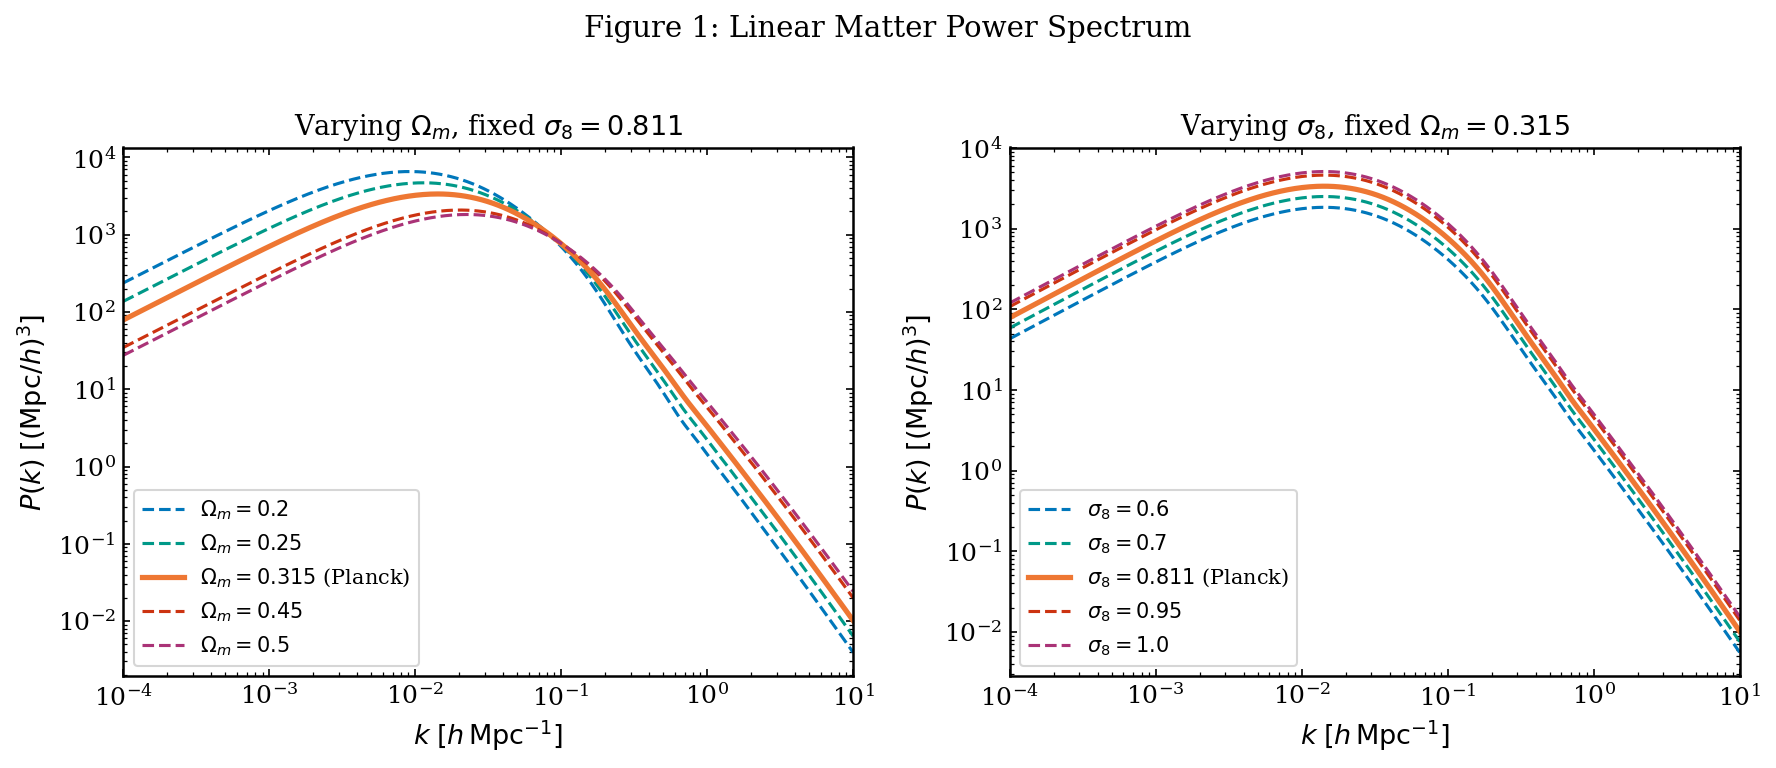

fig1 done


In [7]:
k_arr = np.logspace(-4, 1, 400)

# originally had symmetric spacing, added 0.45 to check behaviour at high Om
om_vals = [0.20, 0.25, 0.315, 0.45, 0.50]
s8_vals = [0.60, 0.70, 0.811, 0.95, 1.00]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
for Om, color in zip(om_vals, COLORS_5):
    Pk  = power_spectrum(k_arr, Om, PLANCK_SIGMA8)
    lw  = 2.5 if Om == PLANCK_OMEGA_M else 1.5
    ls  = '-' if Om == PLANCK_OMEGA_M else '--'
    lbl = f'$\\Omega_m = {Om}$' + (' (Planck)' if Om == PLANCK_OMEGA_M else '')
    ax.loglog(k_arr, Pk, color=color, lw=lw, ls=ls, label=lbl)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
ax.set_title(r'Varying $\Omega_m$, fixed $\sigma_8 = 0.811$')
ax.legend(); ax.set_xlim(1e-4, 10)

ax = axes[1]
for s8, color in zip(s8_vals, COLORS_5):
    Pk  = power_spectrum(k_arr, PLANCK_OMEGA_M, s8)
    lw  = 2.5 if s8 == PLANCK_SIGMA8 else 1.5
    ls  = '-' if s8 == PLANCK_SIGMA8 else '--'
    lbl = f'$\\sigma_8 = {s8}$' + (' (Planck)' if s8 == PLANCK_SIGMA8 else '')
    ax.loglog(k_arr, Pk, color=color, lw=lw, ls=ls, label=lbl)
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P(k)\;[(\mathrm{Mpc}/h)^3]$')
ax.set_title(r'Varying $\sigma_8$, fixed $\Omega_m = 0.315$')
ax.legend(); ax.set_xlim(1e-4, 10)

fig.suptitle('Figure 1: Linear Matter Power Spectrum', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('figures/fig1_power_spectrum.png', bbox_inches='tight', dpi=200)
plt.show()
print('fig1 done')

## Figure 2: Lensing kernel W(chi)

Peak shifts to lower chi (closer structures) for higher Omega_m.
Amplitude scales roughly as Omega_m^2.

computing kernels...


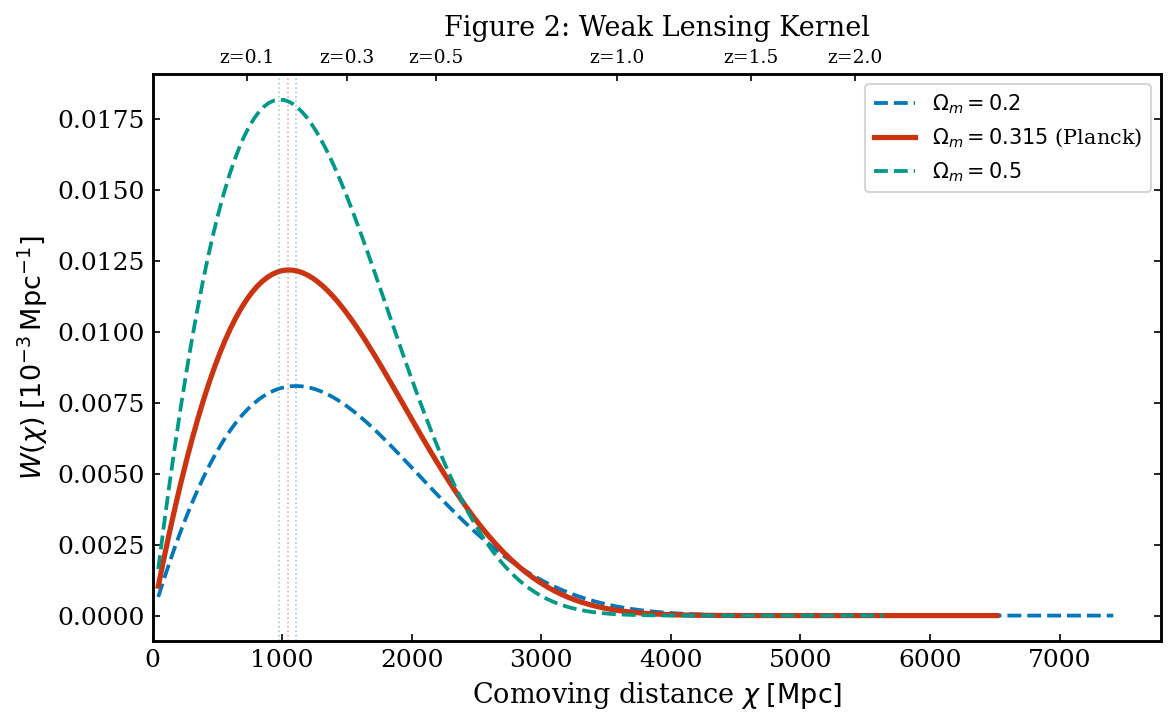

fig2 done


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

om_vals_3 = [0.20, 0.315, 0.50]
colors_3  = [BLUE, RED, GREEN]

print('computing kernels...')
for Om, color in zip(om_vals_3, colors_3):
    chi, W = lensing_kernel(Om)
    lw  = 2.5 if Om == PLANCK_OMEGA_M else 1.8
    ls  = '-' if Om == PLANCK_OMEGA_M else '--'
    lbl = f'$\\Omega_m = {Om}$' + (' (Planck)' if Om == PLANCK_OMEGA_M else '')
    ax.plot(chi, W * 1e3, color=color, lw=lw, ls=ls, label=lbl)
    i_peak = np.argmax(W)
    ax.axvline(chi[i_peak], color=color, lw=0.8, alpha=0.4, ls=':')

# twin axis showing redshift
ax2 = ax.twiny()
z_ticks    = [0.1, 0.3, 0.5, 1.0, 1.5, 2.0]
chi_planck = chi_of_z(np.array(z_ticks), PLANCK_OMEGA_M)
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(chi_planck)
ax2.set_xticklabels([f'z={z}' for z in z_ticks], fontsize=9)

ax.set_xlabel(r'Comoving distance $\chi\;[\mathrm{Mpc}]$')
ax.set_ylabel(r'$W(\chi)\;[10^{-3}\,\mathrm{Mpc}^{-1}]$')
ax.set_title('Figure 2: Weak Lensing Kernel')
ax.legend(); ax.set_xlim(0, None)
plt.tight_layout()
plt.savefig('figures/fig2_lensing_kernel.png', bbox_inches='tight', dpi=200)
plt.show()
print('fig2 done')

## Figures 3 & 4: Shear correlation functions

These are the actual observables -- what UNIONS measures from galaxy ellipticities.
Takes a few minutes. Precomputing all curves first.

In [9]:
# tried 0.28 initially, swapped to 0.30 to bracket Planck more evenly
om_vals = [0.20, 0.25, 0.315, 0.40, 0.50]
s8_vals = [0.60, 0.70, 0.811, 0.90, 1.00]

xi_om = []
print('varying Omega_m...')
for i, Om in enumerate(om_vals):
    print(f'  Om={Om} ({i+1}/{len(om_vals)})')
    xip, xim = compute_xi(Om, PLANCK_SIGMA8)
    xi_om.append((xip, xim))

xi_s8 = []
print('varying sigma_8...')
for i, s8 in enumerate(s8_vals):
    print(f'  s8={s8} ({i+1}/{len(s8_vals)})')
    xip, xim = compute_xi(PLANCK_OMEGA_M, s8)
    xi_s8.append((xip, xim))

print('done')

varying Omega_m...
  Om=0.2 (1/5)
  Om=0.25 (2/5)
  Om=0.315 (3/5)
  Om=0.4 (4/5)
  Om=0.5 (5/5)
varying sigma_8...
  s8=0.6 (1/5)
  s8=0.7 (2/5)
  s8=0.811 (3/5)
  s8=0.9 (4/5)
  s8=1.0 (5/5)
done


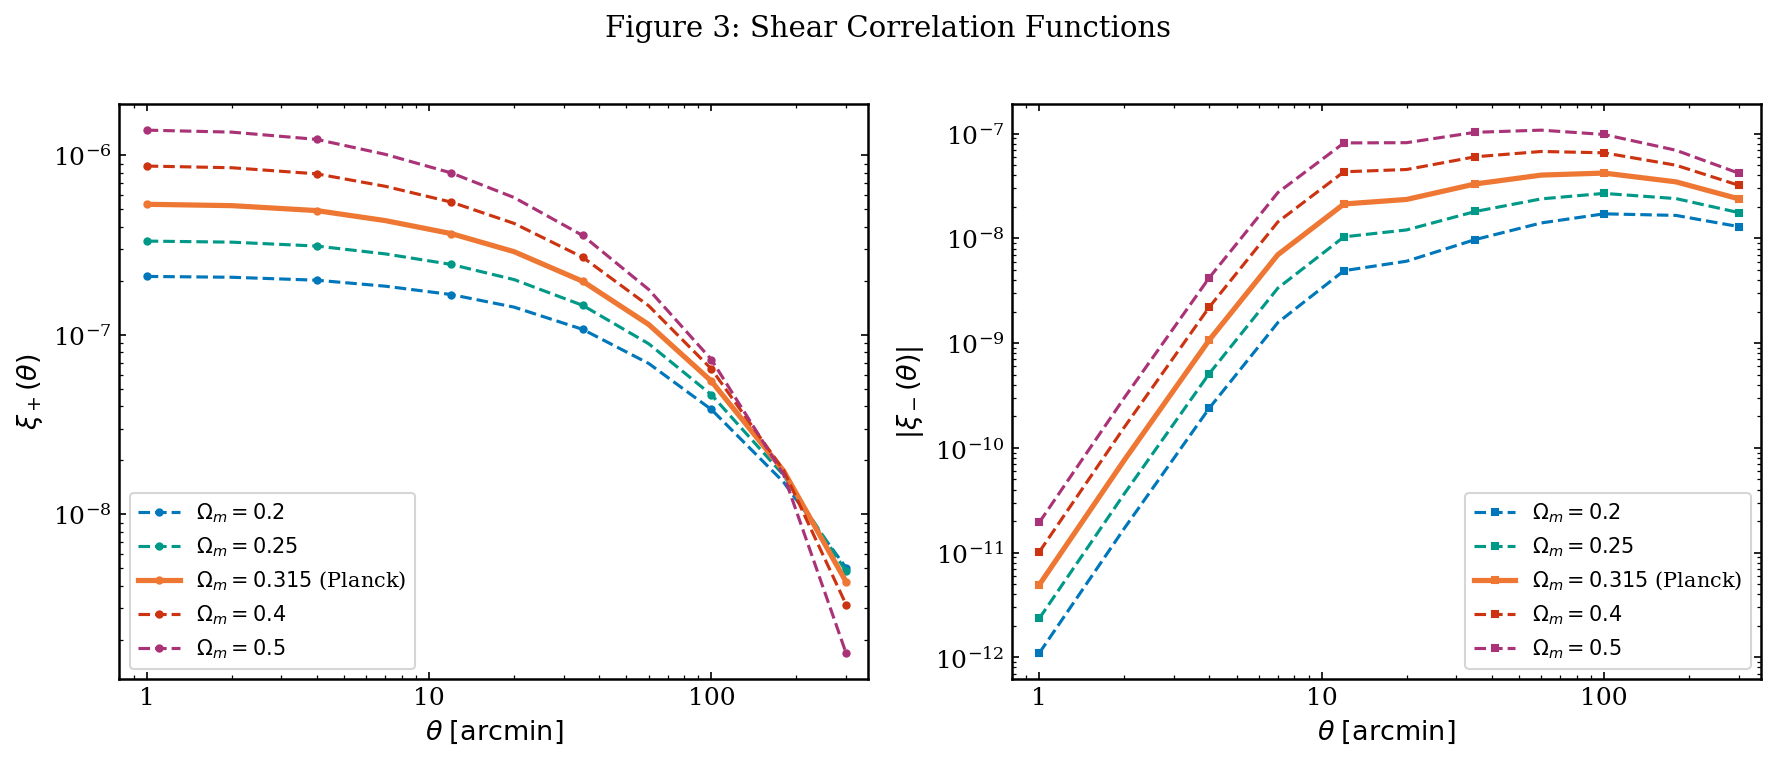

fig3 done


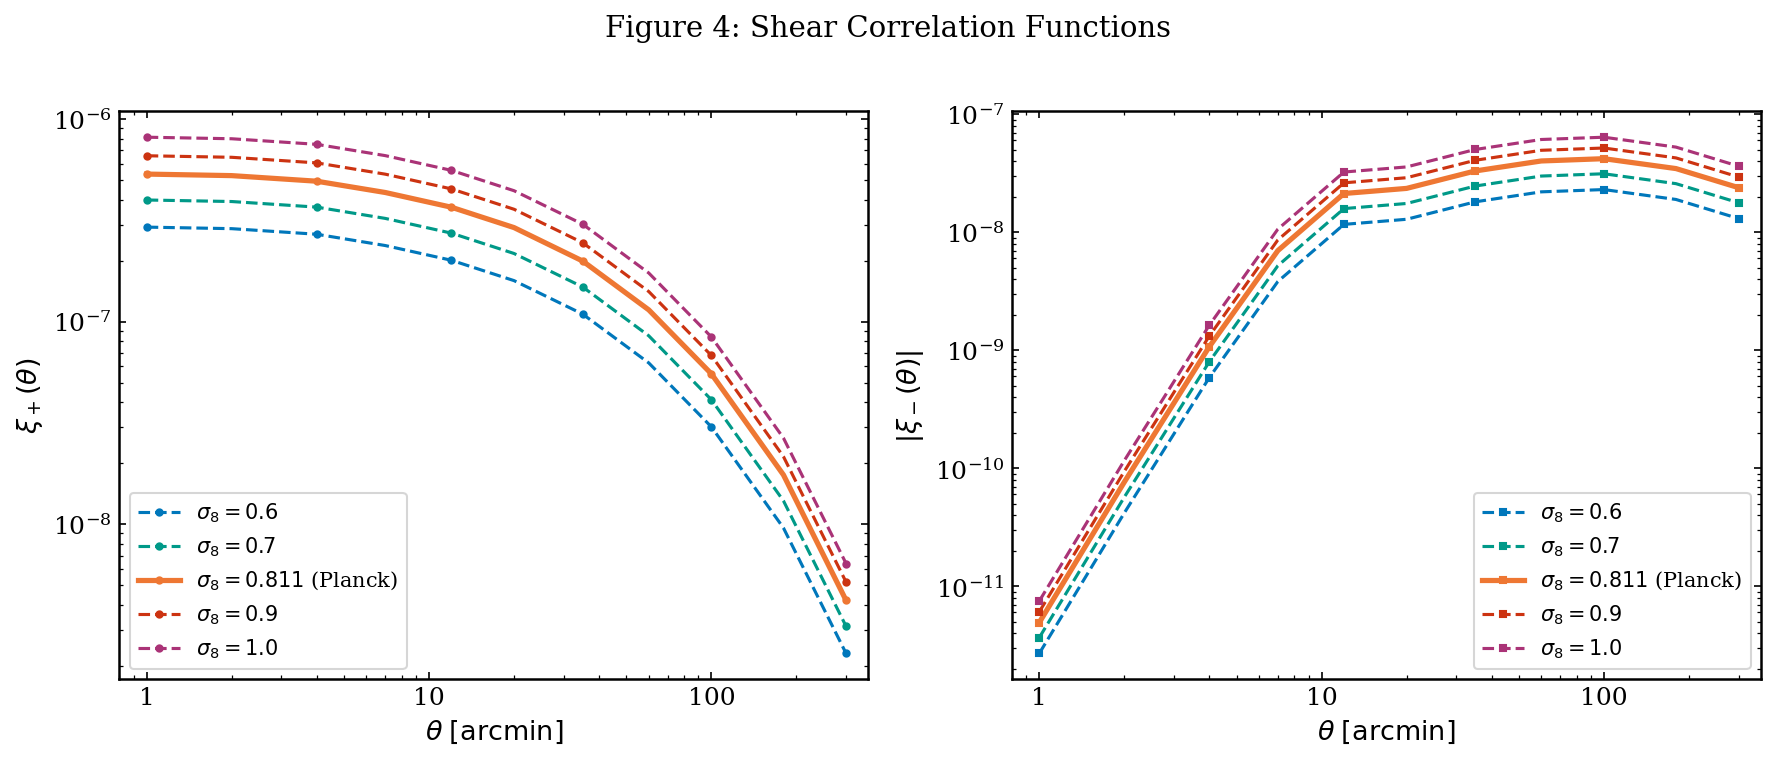

fig4 done


In [10]:
def plot_xi_figure(xi_list, param_vals, param_tex, planck_val, fig_num, filename):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for (xip, xim), val, color in zip(xi_list, param_vals, COLORS_5):
        is_planck = (val == planck_val)
        lw  = 2.5 if is_planck else 1.5
        ls  = '-' if is_planck else '--'
        lbl = f'${param_tex} = {val}$' + (' (Planck)' if is_planck else '')
        axes[0].loglog(THETA_ARCMIN, xip, color=color, lw=lw, ls=ls, label=lbl,
                       marker='o', ms=3, markevery=2)
        axes[1].loglog(THETA_ARCMIN, np.abs(xim), color=color, lw=lw, ls=ls, label=lbl,
                       marker='s', ms=3, markevery=2)
    for ax, ylab in zip(axes, [r'$\xi_+(\theta)$', r'$|\xi_-(\theta)|$']):
        ax.set_xlabel(r'$\theta\;[\mathrm{arcmin}]$')
        ax.set_ylabel(ylab)
        ax.legend()
        ax.set_xlim(THETA_ARCMIN[0]*0.8, THETA_ARCMIN[-1]*1.2)
        ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
    fig.suptitle(f'Figure {fig_num}: Shear Correlation Functions', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f'figures/{filename}.png', bbox_inches='tight', dpi=200)
    plt.show()
    print(f'fig{fig_num} done')

plot_xi_figure(xi_om, om_vals, r'\Omega_m', PLANCK_OMEGA_M, 3, 'fig3_xi_vary_omega_m')
plot_xi_figure(xi_s8, s8_vals, r'\sigma_8', PLANCK_SIGMA8,  4, 'fig4_xi_vary_sigma8')

## Figure 5: S8 tension

S8 = sigma_8 * sqrt(Omega_m/0.3) is the degenerate combination that lensing constrains.
xi_+ scales roughly as sigma_8^2 * Omega_m^0.5ish so there is a diagonal degeneracy
in the (Omega_m, sigma_8) plane -- this is what the S8 contours show.

Planck sits ~3.8 sigma above KiDS-1000. UNIONS should help on the northern sky.

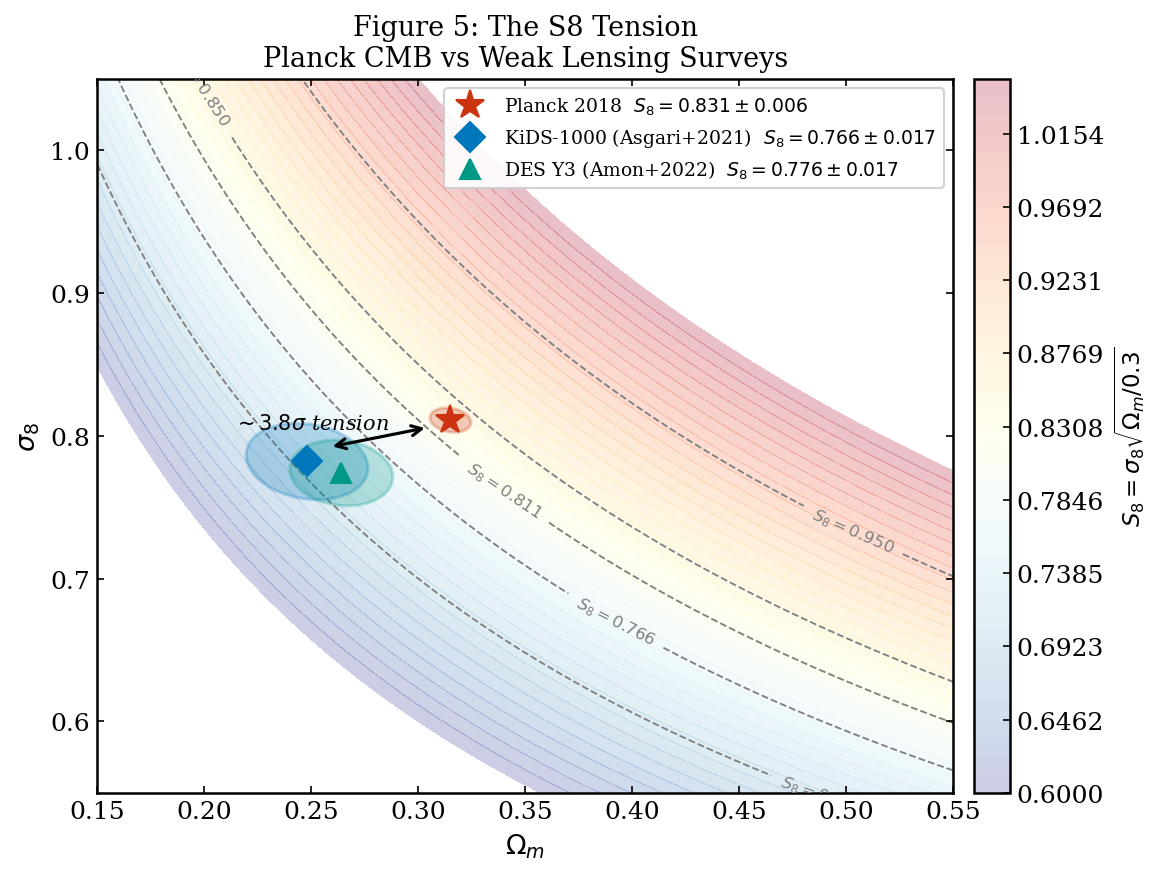

fig5 done


In [15]:
fig, ax = plt.subplots(figsize=(8, 6))

om_bg  = np.linspace(0.15, 0.55, 300)
s8_bg  = np.linspace(0.50, 1.10, 300)
OM, S8 = np.meshgrid(om_bg, s8_bg)
S8_MAP = S8 * np.sqrt(OM / 0.3)

cf = ax.contourf(OM, S8, S8_MAP, levels=np.linspace(0.6, 1.05, 40),
                 cmap='RdYlBu_r', alpha=0.25, zorder=0)
cbar = plt.colorbar(cf, ax=ax, pad=0.02)
cbar.set_label(r'$S_8 = \sigma_8\sqrt{\Omega_m/0.3}$', fontsize=11)

s8_contours = [0.70, 0.766, 0.811, 0.85, 0.95]
cs = ax.contour(OM, S8, S8_MAP, levels=s8_contours,
                colors='grey', linewidths=0.9, linestyles='--', zorder=1)
ax.clabel(cs, fmt=r'$S_8=%.3f$', fontsize=8, inline=True)

# Planck 2018 -- approx 1sigma ellipse from Aghanim+2020 Table 2
# S8 uncertainty propagated from sigma(Omega_m)=0.007, sigma(sigma_8)=0.006
PLANCK_S8_ERR = 0.006
planck_ellipse = Ellipse(xy=(PLANCK_OMEGA_M, PLANCK_SIGMA8),
                         width=2*0.010, height=2*0.008, angle=-30,
                         facecolor=RED, alpha=0.25, edgecolor=RED, lw=1.5, zorder=3)
ax.add_patch(planck_ellipse)
ax.plot(PLANCK_OMEGA_M, PLANCK_SIGMA8, '*', color=RED, ms=14, zorder=4,
        label=f'Planck 2018  $S_8 = {PLANCK_S8:.3f} \\pm {PLANCK_S8_ERR:.3f}$')

# KiDS-1000 -- Asgari et al. (2021), Om~0.248
KIDS_OM, KIDS_S8_VAL = 0.248, 0.782
kids_ellipse = Ellipse(xy=(KIDS_OM, KIDS_S8_VAL),
                       width=2*0.030, height=2*0.025, angle=-35,
                       facecolor=BLUE, alpha=0.25, edgecolor=BLUE, lw=1.5, zorder=3)
ax.add_patch(kids_ellipse)
ax.plot(KIDS_OM, KIDS_S8_VAL, 'D', color=BLUE, ms=10, zorder=4,
        label=f'KiDS-1000 (Asgari+2021)  $S_8 = {KIDS_S8:.3f} \\pm {KIDS_S8_ERR:.3f}$')

# DES Y3 -- Amon et al. (2022)
DES_OM, DES_S8_VAL = 0.264, 0.774
des_ellipse = Ellipse(xy=(DES_OM, DES_S8_VAL),
                      width=2*0.025, height=2*0.022, angle=-35,
                      facecolor=GREEN, alpha=0.25, edgecolor=GREEN, lw=1.5, zorder=3)
ax.add_patch(des_ellipse)
ax.plot(DES_OM, DES_S8_VAL, '^', color=GREEN, ms=10, zorder=4,
        label=f'DES Y3 (Amon+2022)  $S_8 = {DES_S8:.3f} \\pm {DES_S8_ERR:.3f}$')

tension_sigma = (PLANCK_S8 - KIDS_S8) / KIDS_S8_ERR
ax.annotate('', xy=(KIDS_OM+0.01, KIDS_S8_VAL+0.01),
            xytext=(PLANCK_OMEGA_M-0.01, PLANCK_SIGMA8-0.005),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(0.250, 0.805, f'$\\sim{tension_sigma:.1f}\\sigma$ tension',
        fontsize=10, ha='center', style='italic')

ax.set_xlabel(r'$\Omega_m$', fontsize=13)
ax.set_ylabel(r'$\sigma_8$', fontsize=13)
ax.set_title('Figure 5: The S8 Tension\nPlanck CMB vs Weak Lensing Surveys', fontsize=13)
ax.set_xlim(0.15, 0.55); ax.set_ylim(0.55, 1.05)
ax.legend(loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.savefig('figures/fig5_s8_tension.png', bbox_inches='tight', dpi=200)
plt.show()
print('fig5 done')

## Sensitivity analysis

How much does xi_+ change when you shift Omega_m or sigma_8 by 10%?
Plotted as fractional deviation from the Planck fiducial at each angular scale.

sigma_8 shifts the signal by a uniform ~20% -- consistent with xi_+ ~ sigma_8^2.
Omega_m has a scale-dependent effect: stronger at small angles, weaker at large
angles, and changes sign beyond ~200 arcmin due to the Hankel transform.

The scale dependence of the Omega_m response is what makes xi_- useful --
it probes different angular mode combinations and partially breaks the degeneracy.

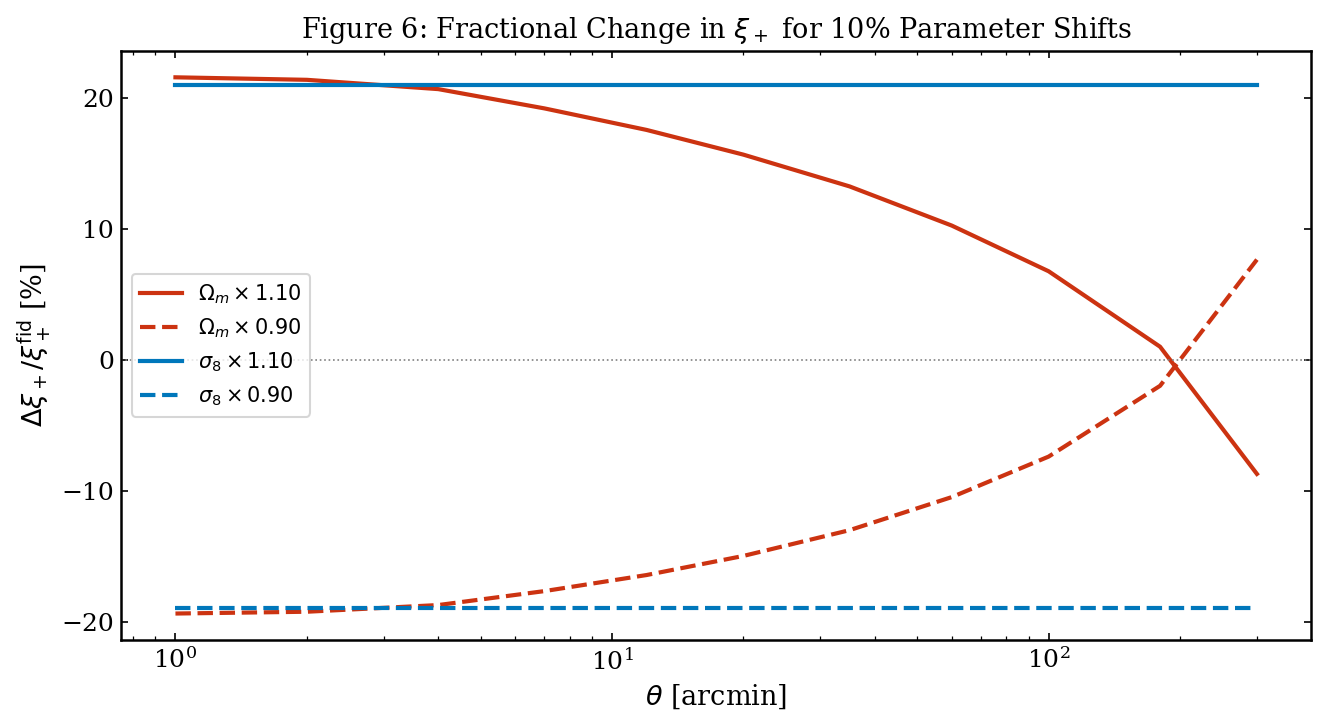

10% increase in Omega_m changes xi_+ by:
  small scales (1 arcmin):  21.6%
  large scales (300 arcmin): -8.7%
10% increase in sigma_8 changes xi_+ by ~21.0% uniformly


In [12]:
xip_fid,  _  = compute_xi(PLANCK_OMEGA_M, PLANCK_SIGMA8)

xip_Om_hi, _ = compute_xi(PLANCK_OMEGA_M * 1.10, PLANCK_SIGMA8)
xip_Om_lo, _ = compute_xi(PLANCK_OMEGA_M * 0.90, PLANCK_SIGMA8)

xip_s8_hi, _ = compute_xi(PLANCK_OMEGA_M, PLANCK_SIGMA8 * 1.10)
xip_s8_lo, _ = compute_xi(PLANCK_OMEGA_M, PLANCK_SIGMA8 * 0.90)

frac_Om_hi = (xip_Om_hi - xip_fid) / xip_fid * 100  # percent
frac_Om_lo = (xip_Om_lo - xip_fid) / xip_fid * 100
frac_s8_hi = (xip_s8_hi - xip_fid) / xip_fid * 100
frac_s8_lo = (xip_s8_lo - xip_fid) / xip_fid * 100

fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogx(THETA_ARCMIN, frac_Om_hi, color=RED,  lw=2.0,
            label=r'$\Omega_m \times 1.10$')
ax.semilogx(THETA_ARCMIN, frac_Om_lo, color=RED,  lw=2.0,
            ls='--', label=r'$\Omega_m \times 0.90$')
ax.semilogx(THETA_ARCMIN, frac_s8_hi, color=BLUE, lw=2.0,
            label=r'$\sigma_8 \times 1.10$')
ax.semilogx(THETA_ARCMIN, frac_s8_lo, color=BLUE, lw=2.0,
            ls='--', label=r'$\sigma_8 \times 0.90$')

ax.axhline(0, color='grey', lw=0.8, ls=':')
ax.set_xlabel(r'$\theta$ [arcmin]')
ax.set_ylabel(r'$\Delta\xi_+ / \xi_+^{\rm fid}$ [%]')
ax.set_title('Figure 6: Fractional Change in $\\xi_+$ for 10% Parameter Shifts')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('figures/fig6_sensitivity.png', bbox_inches='tight', dpi=200)
plt.show()

# report numbers
print(f'10% increase in Omega_m changes xi_+ by:')
print(f'  small scales (1 arcmin):  {frac_Om_hi[0]:.1f}%')
print(f'  large scales (300 arcmin): {frac_Om_hi[-1]:.1f}%')
print(f'10% increase in sigma_8 changes xi_+ by ~{frac_s8_hi.mean():.1f}% uniformly')

## Summary

| Figure | File | Description |
|--------|------|-------------|
| 1 | fig1_power_spectrum.png | P(k) varying Omega_m and sigma_8 |
| 2 | fig2_lensing_kernel.png | W(chi) for different cosmologies |
| 3 | fig3_xi_vary_omega_m.png | xi_+, xi_- varying Omega_m |
| 4 | fig4_xi_vary_sigma8.png | xi_+, xi_- varying sigma_8 |
| 5 | fig5_s8_tension.png | S8 tension: Planck vs lensing surveys |
| 6 | fig6_sensitivity.png | Fractional change in xi_+ for 10% shifts in Omega_m and sigma_8 |